# CLI Tutorial 1: Quick Start

This tutorial introduces a minimal `treem` command-line workflow. The notebook uses Python only to set up paths, run terminal commands, print command output, and display generated images. The actual morphology operations are all done with the `swc` CLI.

## Environment

Set the repository root, switch to the `tutorials/` directory, create local working folders, and define a helper for running `swc` commands.

In [1]:
import os
import shutil
import subprocess
from pathlib import Path

from IPython.display import Image, display


ROOT = Path(
    subprocess.run(
        "git rev-parse --show-toplevel",
        shell=True,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
).resolve()

os.chdir(ROOT / "tutorials")
assert Path.cwd().resolve() == (ROOT / "tutorials").resolve()

Path("data").mkdir(exist_ok=True)
Path("output").mkdir(exist_ok=True)

f = ROOT / "tests" / "data" / "pass_nmo_1.swc"
assert f.exists(), f"Input file not found: {f}"


def quote(value):
    return '"' + str(value).replace('"', '\\"') + '"'


def run_swc(command, image=None, check=False):
    print(f"$ {command}")
    result = subprocess.run(command, shell=True, capture_output=True, text=True)

    print("\nstdout:")
    print(result.stdout.rstrip() or "(empty)")

    print("\nstderr:")
    print(result.stderr.rstrip() or "(empty)")

    print(f"\nreturn code: {result.returncode}")

    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with return code {result.returncode}: {command}")

    if image is not None:
        image_path = Path(image)
        if image_path.exists():
            display(Image(filename=str(image_path)))
        else:
            print(f"Image was not generated: {image_path}")

    return result


print(f"ROOT = {ROOT}")
print(f"working directory = {Path.cwd()}")
print(f"f = {f}")


ROOT = C:\Users\zahra.khodadadi\OneDrive - KTH\Dokument\GitHub\treem
working directory = C:\Users\zahra.khodadadi\OneDrive - KTH\Dokument\GitHub\treem\tutorials
f = C:\Users\zahra.khodadadi\OneDrive - KTH\Dokument\GitHub\treem\tests\data\pass_nmo_1.swc


## Input File

Start with a sample SWC reconstruction from the repository test data. Check whether it is structurally consistent. If the check succeeds, copy it to `./data/inp.swc`; otherwise, convert it to a compliant SWC file.

In [2]:
check_result = run_swc(f"swc check {quote(f)}")

inp = Path("data") / "inp.swc"
if check_result.returncode == 0:
    shutil.copy2(f, inp)
    print(f"Copied {f} to {inp}")
else:
    run_swc(f"swc convert {quote(f)} -o ./data/inp.swc -q", check=True)


$ swc check "C:\Users\zahra.khodadadi\OneDrive - KTH\Dokument\GitHub\treem\tests\data\pass_nmo_1.swc"

stdout:
non_sequential_soma_ids: 3510

stderr:
(empty)

return code: 1
$ swc convert "C:\Users\zahra.khodadadi\OneDrive - KTH\Dokument\GitHub\treem\tests\data\pass_nmo_1.swc" -o ./data/inp.swc -q

stdout:
(empty)

stderr:
(empty)

return code: 0


## View

Visualize the input morphology and save the plot so it can be displayed inside the notebook.

$ swc view ./data/inp.swc -o ./output/inp.png

stdout:
(empty)

stderr:
(empty)

return code: 0


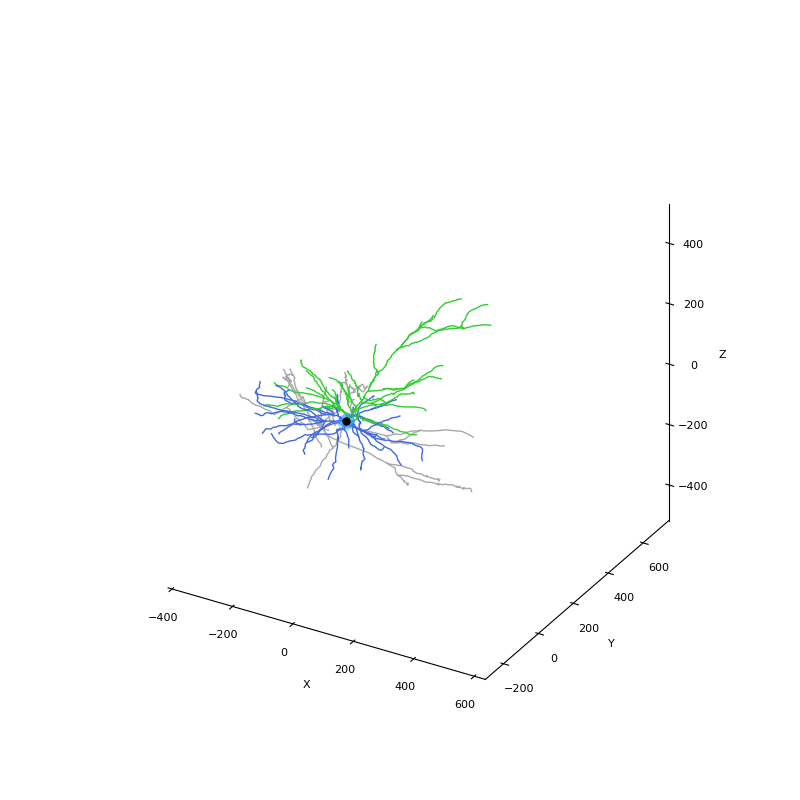

CompletedProcess(args='swc view ./data/inp.swc -o ./output/inp.png', returncode=0, stdout='', stderr='')

In [3]:
run_swc("swc view ./data/inp.swc -o ./output/inp.png", image="output/inp.png", check=True)


## Measure

Measure morphometric features of the working input file.

In [4]:
run_swc("swc measure ./data/inp.swc", check=True)


$ swc measure ./data/inp.swc

stdout:
inp
apic area        12266.1
apic breadth          32
apic contrac    0.932844
apic degree            2
apic diam       0.816706
apic dist        748.044
apic length      5690.72
apic nbranch          31
apic nstem             1
apic nterm            32
apic order            18
apic seclen      90.3288
apic volume      2330.54
apic xdim         452.39
apic ydim         760.58
apic zdim         157.55
axon area        3594.75
axon breadth          43
axon contrac    0.875142
axon degree            2
axon diam       0.229008
axon dist        610.746
axon length      4935.25
axon nbranch          42
axon nstem             1
axon nterm            43
axon order            16
axon seclen      58.0618
axon volume      226.353
axon xdim         890.59
axon ydim         466.28
axon zdim         147.85
dend area         9444.9
dend breadth          10
dend contrac    0.927556
dend degree            2
dend diam       0.636772
dend dist         292.67
dend len

CompletedProcess(args='swc measure ./data/inp.swc', returncode=0, stdout='inp\napic area        12266.1\napic breadth          32\napic contrac    0.932844\napic degree            2\napic diam       0.816706\napic dist        748.044\napic length      5690.72\napic nbranch          31\napic nstem             1\napic nterm            32\napic order            18\napic seclen      90.3288\napic volume      2330.54\napic xdim         452.39\napic ydim         760.58\napic zdim         157.55\naxon area        3594.75\naxon breadth          43\naxon contrac    0.875142\naxon degree            2\naxon diam       0.229008\naxon dist        610.746\naxon length      4935.25\naxon nbranch          42\naxon nstem             1\naxon nterm            43\naxon order            16\naxon seclen      58.0618\naxon volume      226.353\naxon xdim         890.59\naxon ydim         466.28\naxon zdim         147.85\ndend area         9444.9\ndend breadth          10\ndend contrac    0.927556\ndend degree

## Modify

Scale the morphology by a factor of `2` along the x, y, and z axes, and write the modified reconstruction to `./output/scaled.swc`.

In [5]:
run_swc("swc modify ./data/inp.swc -s 2 2 2 -o ./output/scaled.swc", check=True)


$ swc modify ./data/inp.swc -s 2 2 2 -o ./output/scaled.swc

stdout:
(empty)

stderr:
(empty)

return code: 0


CompletedProcess(args='swc modify ./data/inp.swc -s 2 2 2 -o ./output/scaled.swc', returncode=0, stdout='', stderr='')

## Compare

View and measure the original working copy and the scaled reconstruction together.

$ swc view ./data/inp.swc ./output/scaled.swc -c cells -o ./output/compare.png

stdout:
(empty)

stderr:
(empty)

return code: 0


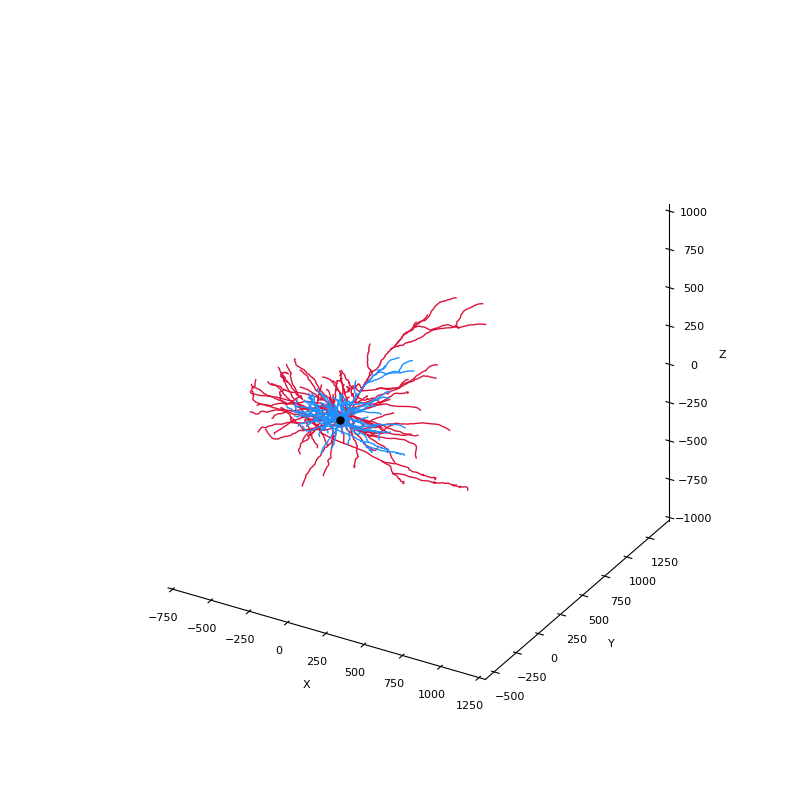

CompletedProcess(args='swc view ./data/inp.swc ./output/scaled.swc -c cells -o ./output/compare.png', returncode=0, stdout='', stderr='')

In [6]:
run_swc(
    "swc view ./data/inp.swc ./output/scaled.swc -c cells -o ./output/compare.png",
    image="output/compare.png",
    check=True,
)


In [7]:
run_swc("swc measure ./data/inp.swc ./output/scaled.swc", check=True)


$ swc measure ./data/inp.swc ./output/scaled.swc

stdout:
inp
apic area        12266.1
apic breadth          32
apic contrac    0.932844
apic degree            2
apic diam       0.816706
apic dist        748.044
apic length      5690.72
apic nbranch          31
apic nstem             1
apic nterm            32
apic order            18
apic seclen      90.3288
apic volume      2330.54
apic xdim         452.39
apic ydim         760.58
apic zdim         157.55
axon area        3594.75
axon breadth          43
axon contrac    0.875142
axon degree            2
axon diam       0.229008
axon dist        610.746
axon length      4935.25
axon nbranch          42
axon nstem             1
axon nterm            43
axon order            16
axon seclen      58.0618
axon volume      226.353
axon xdim         890.59
axon ydim         466.28
axon zdim         147.85
dend area         9444.9
dend breadth          10
dend contrac    0.927556
dend degree            2
dend diam       0.636772
dend dist    

CompletedProcess(args='swc measure ./data/inp.swc ./output/scaled.swc', returncode=0, stdout='inp\napic area        12266.1\napic breadth          32\napic contrac    0.932844\napic degree            2\napic diam       0.816706\napic dist        748.044\napic length      5690.72\napic nbranch          31\napic nstem             1\napic nterm            32\napic order            18\napic seclen      90.3288\napic volume      2330.54\napic xdim         452.39\napic ydim         760.58\napic zdim         157.55\naxon area        3594.75\naxon breadth          43\naxon contrac    0.875142\naxon degree            2\naxon diam       0.229008\naxon dist        610.746\naxon length      4935.25\naxon nbranch          42\naxon nstem             1\naxon nterm            43\naxon order            16\naxon seclen      58.0618\naxon volume      226.353\naxon xdim         890.59\naxon ydim         466.28\naxon zdim         147.85\ndend area         9444.9\ndend breadth          10\ndend contrac    0